In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:

import pandas as pd

df = pd.read_csv("student_dataset_v2 (1).csv")

df.head()

,ID,Name,StudyHours,Attendance,Marks
0,1,Student_1,4.4,96,59.5
1,2,Student_2,9.6,61,60.0
2,3,Student_3,7.6,65,80.2
3,4,Student_4,6.4,73,99.6
4,5,Student_5,2.4,68,79.7


# # EduVision — Student Performance Analytics & Prediction

## 1. Dataset Overview

This project analyzes student academic data and develops a machine learning model to predict student marks based on study hours and attendance.

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (1000, 5)

Column Names:
['ID', 'Name', 'StudyHours', 'Attendance', 'Marks']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1000 non-null   int64  
 1   Name        1000 non-null   object 
 2   StudyHours  1000 non-null   float64
 3   Attendance  1000 non-null   int64  
 4   Marks       951 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 39.2+ KB


In [6]:
df.describe()

,ID,StudyHours,Attendance,Marks
count,1000.000000,1000.000000,1000.000000,951.000000
mean,500.500000,5.413500,75.122000,69.991377
std,288.819436,2.630701,14.692208,17.287756
min,1.000000,1.000000,50.000000,40.000000
25%,250.750000,3.100000,62.000000,55.600000
50%,500.500000,5.500000,75.000000,70.300000
75%,750.250000,7.700000,88.000000,85.100000
max,1000.000000,10.000000,100.000000,99.900000


# ## 2. Data Quality Analysis

Before building the machine learning model, the dataset is checked for missing values and duplicate records.

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID             0
Name           0
StudyHours     0
Attendance     0
Marks         49
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
ID,0,0.0
Name,0,0.0
StudyHours,0,0.0
Attendance,0,0.0
Marks,49,4.9


In [10]:
df["Marks"] = df["Marks"].fillna(df["Marks"].median())

In [11]:
print(df.isnull().sum())

ID            0
Name          0
StudyHours    0
Attendance    0
Marks         0
dtype: int64


In [12]:
df = df.drop(columns=["ID", "Name"])

In [13]:
df.head()

,StudyHours,Attendance,Marks
0,4.4,96,59.5
1,9.6,61,60.0
2,7.6,65,80.2
3,6.4,73,99.6
4,2.4,68,79.7


In [14]:
df.dtypes

StudyHours    float64
Attendance      int64
Marks         float64
dtype: object

# ## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the relationships between study hours, attendance, and student marks.

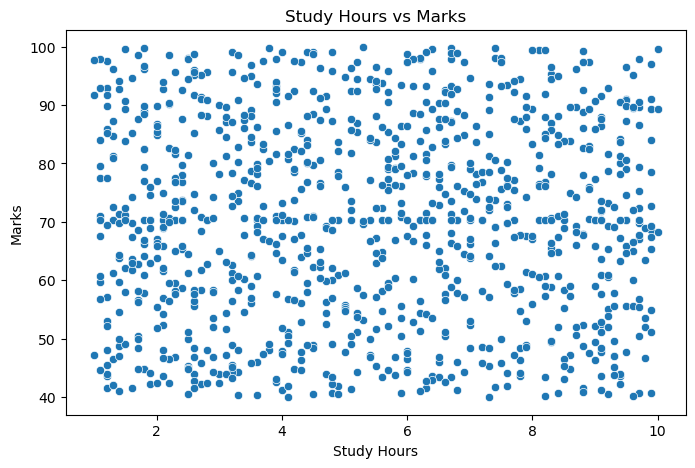

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="StudyHours",
    y="Marks"
)

plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.show()

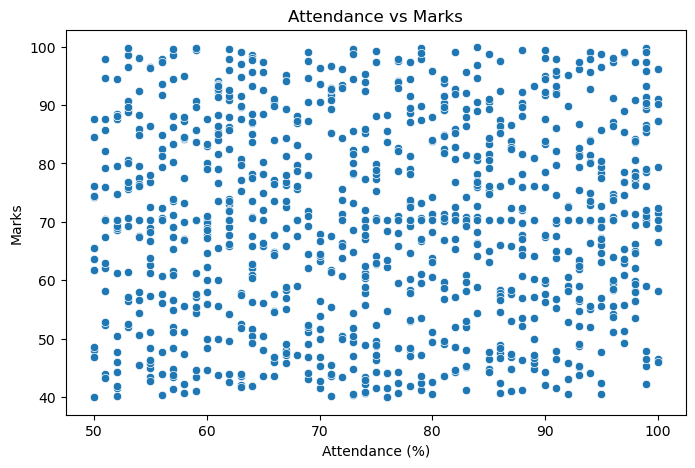

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Marks"
)

plt.title("Attendance vs Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Marks")

plt.show()

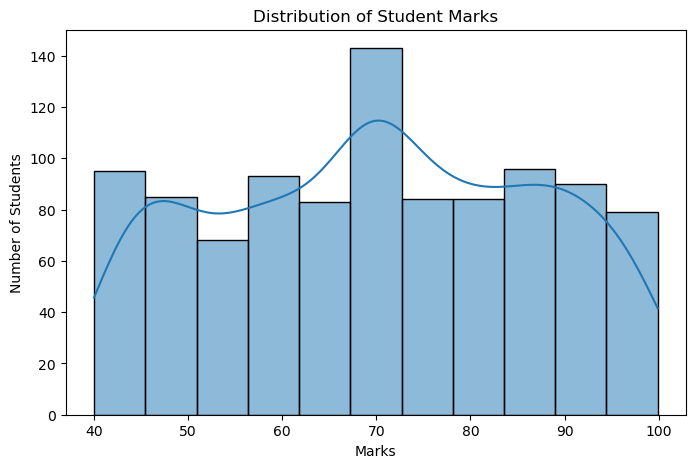

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Marks",
    kde=True
)

plt.title("Distribution of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")

plt.show()

In [18]:
correlation = df.corr(numeric_only=True)

correlation

,StudyHours,Attendance,Marks
StudyHours,1.000000,0.033247,0.021393
Attendance,0.033247,1.000000,0.029583
Marks,0.021393,0.029583,1.000000


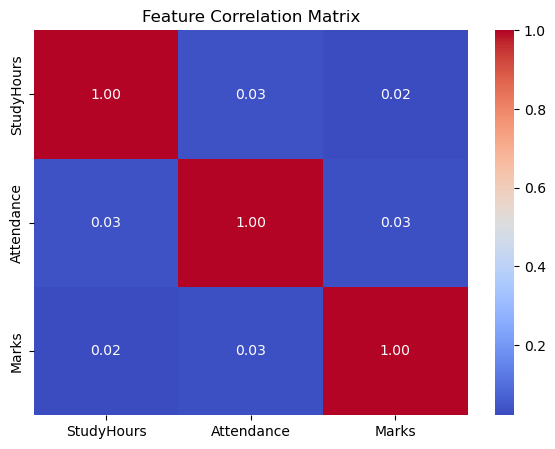

In [19]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

# ## 4. Feature Selection

Study hours and attendance are used as input features, while student marks are used as the target variable.

In [20]:
X = df[["StudyHours", "Attendance"]]

y = df["Marks"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   StudyHours  Attendance
0         4.4          96
1         9.6          61
2         7.6          65
3         6.4          73
4         2.4          68

Target:
0    59.5
1    60.0
2    80.2
3    99.6
4    79.7
Name: Marks, dtype: float64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


# ## 5. Machine Learning Model

A Linear Regression model is used to predict student marks based on study hours and attendance.

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = model.predict(X_test)

print("Predicted Marks:")
print(y_pred[:10])

Predicted Marks:
[69.50118122 70.04544364 69.05659681 70.75515205 71.09956696 71.3660627
 69.26438313 70.21431896 69.68583697 69.39170119]


# ## 6. Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [24]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Performance
------------------
MAE  : 14.450343381890399
MSE  : 281.0182044364919
RMSE : 16.763597598263086
R²   : -0.0024725022357678927


In [25]:
results = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

results.head(10)

,Actual Marks,Predicted Marks
0,83.2,69.501181
1,78.2,70.045444
2,92.4,69.056597
3,79.1,70.755152
4,65.1,71.099567
5,56.8,71.366063
6,54.4,69.264383
7,78.1,70.214319
8,94.6,69.685837
9,70.3,69.391701


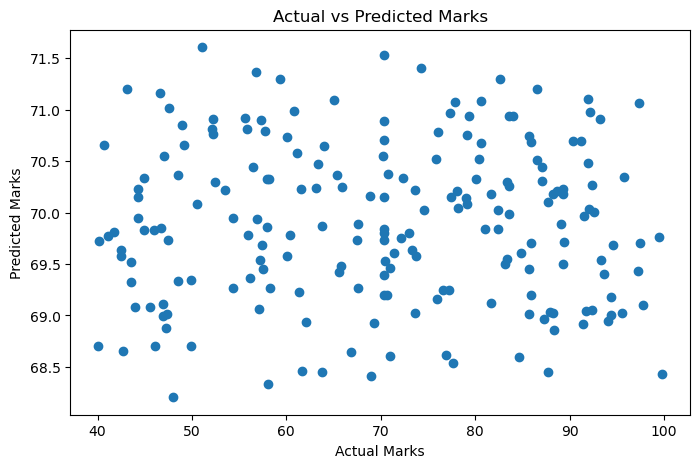

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

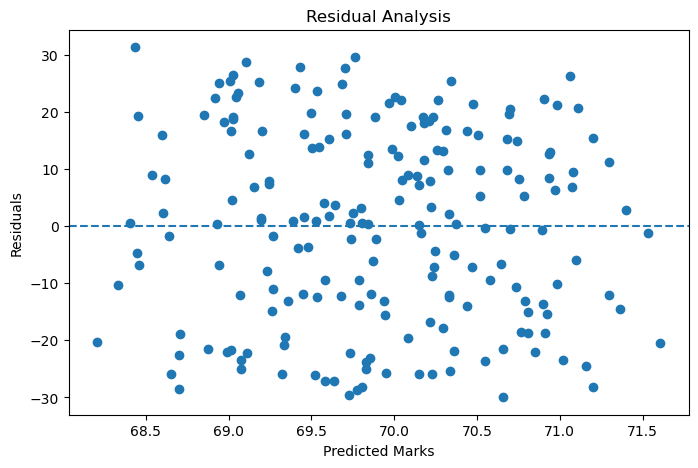

In [27]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.show()

In [28]:
study_hours = 6
attendance = 85

new_student = pd.DataFrame({
    "StudyHours": [study_hours],
    "Attendance": [attendance]
})

predicted_marks = model.predict(new_student)

print("Predicted Marks:", predicted_marks[0])

Predicted Marks: 70.48208923301173


In [29]:
df.corr(numeric_only=True)

,StudyHours,Attendance,Marks
StudyHours,1.000000,0.033247,0.021393
Attendance,0.033247,1.000000,0.029583
Marks,0.021393,0.029583,1.000000


In [30]:
df = pd.read_csv("student_dataset_v2 (1).csv")

print("Original shape:", df.shape)

df = df.dropna(subset=["Marks"])

df = df.drop(columns=["ID", "Name"])

print("After cleaning:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Original shape: (1000, 5)
After cleaning: (951, 3)

Missing values:
StudyHours    0
Attendance    0
Marks         0
dtype: int64


In [31]:
df.corr(numeric_only=True)

,StudyHours,Attendance,Marks
StudyHours,1.000000,0.027683,0.021811
Attendance,0.027683,1.000000,0.030244
Marks,0.021811,0.030244,1.000000


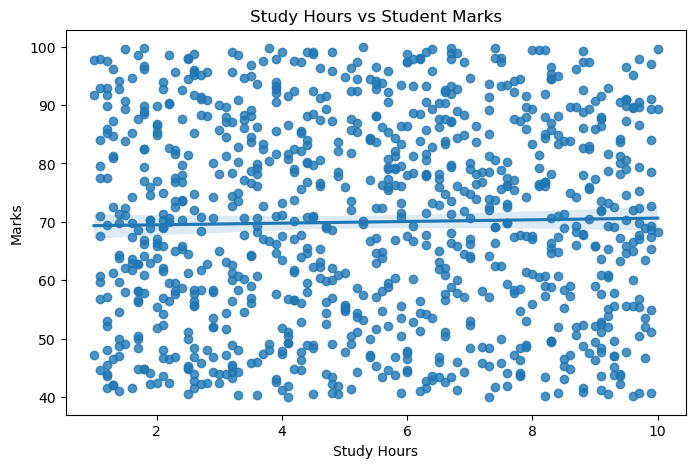

In [32]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="StudyHours",
    y="Marks"
)

plt.title("Study Hours vs Student Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")

plt.show()

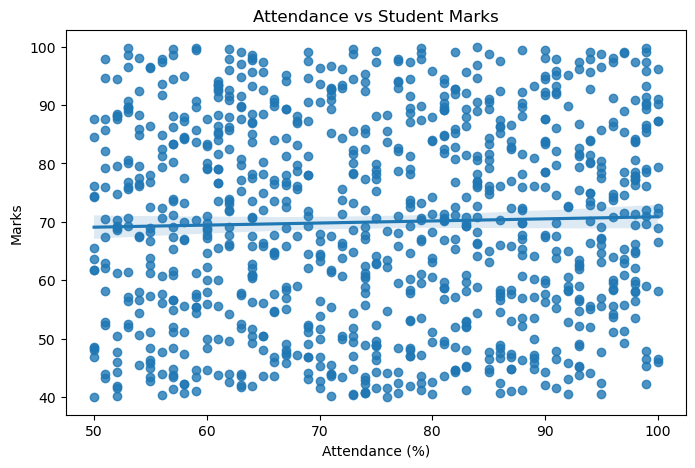

In [33]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="Attendance",
    y="Marks"
)

plt.title("Attendance vs Student Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Marks")

plt.show()

## Conclusion

The exploratory analysis shows that StudyHours and Attendance have very weak linear relationships with Marks in the available dataset. The regression model therefore provides limited predictive performance.

The analysis demonstrates the complete data science workflow, including data cleaning, exploratory data analysis, correlation analysis, visualization, train-test splitting, model training, and evaluation.